In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Video formats & conversion (FFmpeg/OpenCV)

# OpenCV – read/write to a standard format/codec

In [4]:
import cv2, os
from IPython.display import HTML
from base64 import b64encode

cap = cv2.VideoCapture("/kaggle/input/videos1/282995_small.mp4")
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
fps = cap.get(cv2.CAP_PROP_FPS) or 30
w  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter("standardized.mp4", fourcc, fps, (w, h))
while True:
    ok, frame = cap.read()
    if not ok: break
    out.write(frame)

cap.release(); out.release()

print("---> Preprocessing Done:")
print(f"- Video standardized to {w}x{h} resolution")
print(f"- Frame rate fixed at {fps} FPS")
print("---> Saved as standardized.mp4")

mp4 = open("standardized.mp4",'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width=600 controls>
  <source src="{data_url}" type="video/mp4">
</video>
""")

---> Preprocessing Done:
- Video standardized to 224x224 resolution
- Frame rate fixed at 29.97 FPS
---> Saved as standardized.mp4


# Resizing (up/downscaling)

In [3]:
import cv2
from IPython.display import HTML
from base64 import b64encode

def resize_video(in_path, out_path, size=(224,224), interp=cv2.INTER_AREA):
    cap = cv2.VideoCapture(in_path)
    if not cap.isOpened():
        print("Error: Unable to open the video.")
        return
    
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    out = cv2.VideoWriter(out_path, fourcc, fps, size)
    
    print(f"- Starting video resize process:")
    print(f"- Input video resolution: {w}x{h}")
    print(f"- Output video resolution: {size[0]}x{size[1]}")
    print(f"- FPS: {fps}")
    
    while True:
        ok, frame = cap.read()
        if not ok: break
        resized = cv2.resize(frame, size, interpolation=interp)
        out.write(resized)
    
    cap.release()
    out.release()
    
    print("- Preprocessing Complete! Output video saved as:", out_path)
    
    mp4 = open(out_path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    
    return HTML(f"""
    <video width=600 controls>
      <source src="{data_url}" type="video/mp4">
    </video>
    """)
    
resize_video("/kaggle/input/videos1/282995_small.mp4", "resized_224.mp4", (224, 224))

✅ Starting video resize process:
- Input video resolution: 1920x1080
- Output video resolution: 224x224
- FPS: 29.97002997002997
✅ Preprocessing Complete! Output video saved as: resized_224.mp4


# Downsample FPS with FFmpeg

In [5]:
!apt-get update
!apt-get install ffmpeg -y

# Step 2: Check if FFmpeg is installed correctly
!ffmpeg -version

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]        
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]      
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]           
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]      
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,939 kB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease [24.3 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [3,569 kB]
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InR

In [6]:
!ffmpeg -i /kaggle/input/videos1/282995_small.mp4 -r 15 -c:v libx264 -crf 23 -c:a copy output_15fps.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

# Programmatic downsample (keep every Nth frame)

In [8]:
import cv2

def change_fps_keep_every_n(in_path, out_path, target_fps=10):
    cap = cv2.VideoCapture(in_path)
    if not cap.isOpened():
        print(f"Error: Unable to open the video file {in_path}")
        return
    
    src_fps = cap.get(cv2.CAP_PROP_FPS) or 30
    keep_every = max(1, round(src_fps / target_fps))
    w, h = (int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
            int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))
    
    print(f"- Source FPS: {src_fps}")
    print(f"- Target FPS: {target_fps}")
    print(f"- Calculated frame interval: Keep every {keep_every} frame(s)")
    
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out = cv2.VideoWriter(out_path, fourcc, target_fps, (w,h))
    
    print(f"- Output video will be saved as: {out_path}")
    print(f"- Output resolution: {w}x{h}")
    
    idx = 0
    frame_count = 0
    while True:
        ok, frame = cap.read()
        if not ok: break
        if idx % keep_every == 0:
            out.write(frame)
            frame_count += 1
            print(f"🖼️ Frame {idx} kept and written to output.")
        
        idx += 1
    
    cap.release()
    out.release()
    
    print(f"- Processing Complete! {frame_count} frames written to {out_path}")

change_fps_keep_every_n("/kaggle/input/videos1/282995_small.mp4", "output_15fps.mp4", 10)

✅ Source FPS: 29.97002997002997
✅ Target FPS: 10
✅ Calculated frame interval: Keep every 3 frame(s)
✅ Output video will be saved as: output_15fps.mp4
✅ Output resolution: 1920x1080
🖼️ Frame 0 kept and written to output.
🖼️ Frame 3 kept and written to output.
🖼️ Frame 6 kept and written to output.
🖼️ Frame 9 kept and written to output.
🖼️ Frame 12 kept and written to output.
🖼️ Frame 15 kept and written to output.
🖼️ Frame 18 kept and written to output.
🖼️ Frame 21 kept and written to output.
🖼️ Frame 24 kept and written to output.
🖼️ Frame 27 kept and written to output.
🖼️ Frame 30 kept and written to output.
🖼️ Frame 33 kept and written to output.
🖼️ Frame 36 kept and written to output.
🖼️ Frame 39 kept and written to output.
🖼️ Frame 42 kept and written to output.
🖼️ Frame 45 kept and written to output.
🖼️ Frame 48 kept and written to output.
🖼️ Frame 51 kept and written to output.
🖼️ Frame 54 kept and written to output.
🖼️ Frame 57 kept and written to output.
🖼️ Frame 60 kept and wr

# Color space conversion

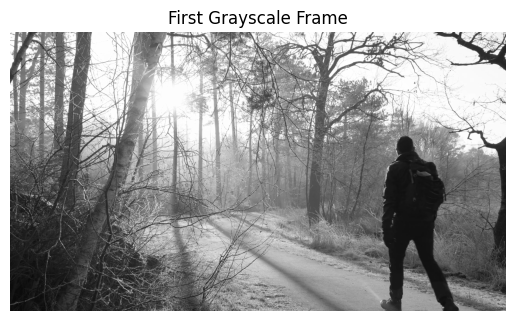

In [9]:
import cv2
from matplotlib import pyplot as plt

cap = cv2.VideoCapture("/kaggle/input/videos1/282995_small.mp4")
fps = cap.get(cv2.CAP_PROP_FPS) or 30
w, h = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

ok, frame = cap.read()
if ok:
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    plt.imshow(gray, cmap='gray')
    plt.title("First Grayscale Frame")
    plt.axis("off")  
    plt.show()

cap.release()

In [10]:
import cv2

cap = cv2.VideoCapture("/kaggle/input/videos1/282995_small.mp4")
if not cap.isOpened():
    print("Error: Cant open the video")
    exit()

fps = cap.get(cv2.CAP_PROP_FPS) or 30
w, h = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out_gray = cv2.VideoWriter("grayscale_video.mp4", fourcc, fps, (w, h), isColor=False)

frame_count = 0
while True:
    ok, frame = cap.read()
    if not ok:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    out_gray.write(gray)
    
    frame_count += 1
    if frame_count % 100 == 0:  
        print(f"Processed {frame_count} frames...")

cap.release()
out_gray.release()

print(f"- Video processing complete! Grayscale video saved as 'grayscale_video.mp4'.")

Processed 100 frames...
Processed 200 frames...
Processed 300 frames...
Processed 400 frames...
✅ Video processing complete! Grayscale video saved as 'gray_video.mp4'.


# Frame extraction

In [12]:
import cv2, os

def extract_frames(video, out_dir, every_n=1):
    os.makedirs(out_dir, exist_ok=True)
    cap = cv2.VideoCapture(video)
    if not cap.isOpened():
        print("Error: Cant open the video")
        return
    
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    print(f"Processing video: {video}")
    print(f"FPS: {fps}, Total frames: {total_frames}")
    
    idx = 0
    saved = 0
    
    while True:
        ok, frame = cap.read()
        if not ok: break
        
        if idx % every_n == 0:
            cv2.imwrite(f"{out_dir}/frame_{saved:06d}.jpg", frame)
            saved += 1
            print(f"Saved frame {saved} at index {idx}")
        
        idx += 1
    
    cap.release()
    print(f"Extracted {saved} frames and saved them in {out_dir}")

extract_frames("/kaggle/input/videos1/282995_small.mp4", "frames", every_n=1)

Processing video: /kaggle/input/videos1/282995_small.mp4
FPS: 29.97002997002997, Total frames: 423
Saved frame 1 at index 0
Saved frame 2 at index 1
Saved frame 3 at index 2
Saved frame 4 at index 3
Saved frame 5 at index 4
Saved frame 6 at index 5
Saved frame 7 at index 6
Saved frame 8 at index 7
Saved frame 9 at index 8
Saved frame 10 at index 9
Saved frame 11 at index 10
Saved frame 12 at index 11
Saved frame 13 at index 12
Saved frame 14 at index 13
Saved frame 15 at index 14
Saved frame 16 at index 15
Saved frame 17 at index 16
Saved frame 18 at index 17
Saved frame 19 at index 18
Saved frame 20 at index 19
Saved frame 21 at index 20
Saved frame 22 at index 21
Saved frame 23 at index 22
Saved frame 24 at index 23
Saved frame 25 at index 24
Saved frame 26 at index 25
Saved frame 27 at index 26
Saved frame 28 at index 27
Saved frame 29 at index 28
Saved frame 30 at index 29
Saved frame 31 at index 30
Saved frame 32 at index 31
Saved frame 33 at index 32
Saved frame 34 at index 33
Sa

# Frame sampling (uniform/random/keyframe)

In [13]:
import cv2, numpy as np, random

def uniform_indices(num_frames, k): 
    indices = np.linspace(0, num_frames-1, k).astype(int).tolist()
    print(f"Uniformly selected indices: {indices}")
    return indices

def random_indices(num_frames, k):
    indices = sorted(random.sample(range(num_frames), k))
    print(f"Randomly selected indices: {indices}")
    return indices

def count_frames(video):
    cap = cv2.VideoCapture(video)
    if not cap.isOpened():
        print("Error: Cant open the video")
        return 0
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    print(f"Total number of frames in the video: {n}")
    return n

def read_frames_by_index(video, indices):
    cap = cv2.VideoCapture(video)
    frames = []
    for i in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ok, f = cap.read()
        if ok:
            frames.append(f)
            print(f"Frame {i} read successfully")
        else:
            print(f"Error reading frame {i}")
    cap.release()
    print(f"Total frames read: {len(frames)}")
    return frames

def keyframe_indices(video, k=16, step=5, thr=0.5):
    cap = cv2.VideoCapture(video)
    idx = 0
    prev_hist = None
    scores = []
    while True:
        ok, frame = cap.read()
        if not ok: break
        if idx % step == 0:
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            hist = cv2.calcHist([gray], [0], None, [64], [0, 256])
            hist = cv2.normalize(hist, None).flatten()
            score = 0 if prev_hist is None else float(np.linalg.norm(hist - prev_hist))
            scores.append((idx, score))
            prev_hist = hist
            print(f"Frame {idx}: Histogram score = {score}")
        idx += 1
    cap.release()
    scores.sort(key=lambda x: x[1], reverse=True)
    keyframe_idxs = sorted([i for i, _ in scores[:k]])
    print(f"Selected keyframe indices: {keyframe_idxs}")
    return keyframe_idxs

n = count_frames("/kaggle/input/videos1/282995_small.mp4")
idxs = uniform_indices(n, 16)
frames = read_frames_by_index("/kaggle/input/videos1/282995_small.mp4", idxs)

Total number of frames in the video: 423
Uniformly selected indices: [0, 28, 56, 84, 112, 140, 168, 196, 225, 253, 281, 309, 337, 365, 393, 422]
Frame 0 read successfully
Frame 28 read successfully
Frame 56 read successfully
Frame 84 read successfully
Frame 112 read successfully
Frame 140 read successfully
Frame 168 read successfully
Frame 196 read successfully
Frame 225 read successfully
Frame 253 read successfully
Frame 281 read successfully
Frame 309 read successfully
Frame 337 read successfully
Frame 365 read successfully
Frame 393 read successfully
Frame 422 read successfully
Total frames read: 16


# Temporal processing (shot boundary, scene segmentation, optical flow)

Cut detected at frame 24, histogram difference = 1.0774705410003662
Cut detected at frame 25, histogram difference = 1.0525275468826294
Cut detected at frame 30, histogram difference = 1.2171175479888916
Cut detected at frame 35, histogram difference = 1.117512822151184
Cut detected at frame 41, histogram difference = 1.0513497591018677
Cut detected at frame 42, histogram difference = 1.039506435394287
Cut detected at frame 54, histogram difference = 1.2671514749526978
Cut detected at frame 314, histogram difference = 1.2119590044021606
Cut detected at frame 319, histogram difference = 0.9620223641395569
Cut detected at frame 432, histogram difference = 1.0837911367416382
Total cuts detected: 10


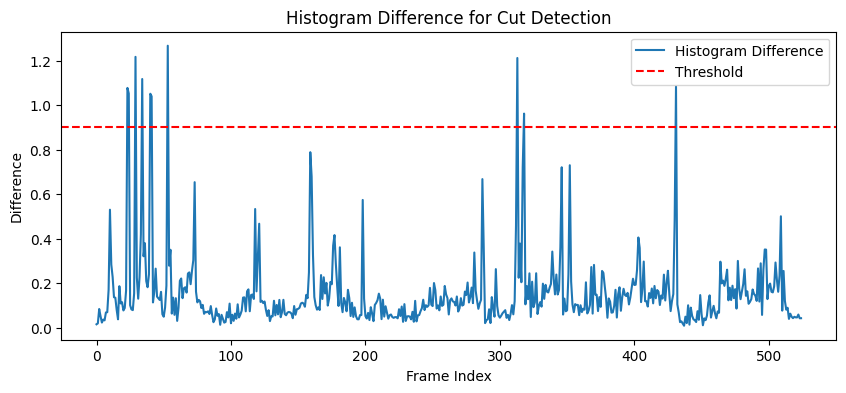

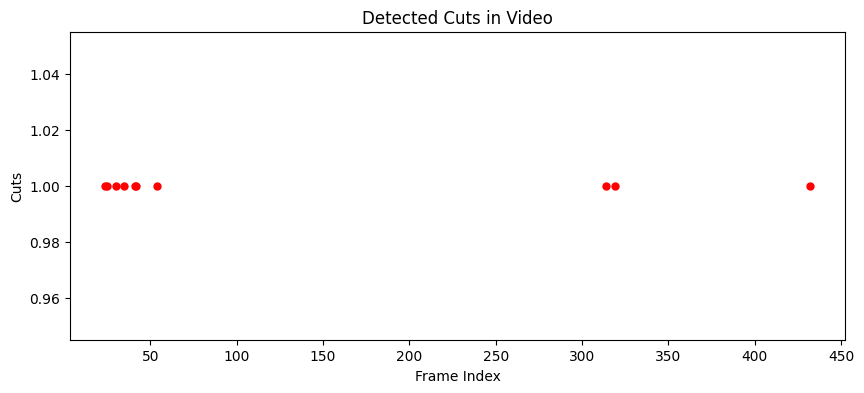

In [29]:
import cv2, numpy as np
import matplotlib.pyplot as plt

def detect_cuts(video, thresh=0.9):
    cap = cv2.VideoCapture(video)
    if not cap.isOpened():
        print("Error: Cant open the video")
        return []
    
    cuts = []
    prev = None
    idx = 0
    diff_values = []
    
    while True:
        ok, f = cap.read()
        if not ok:
            break
        
        hsv = cv2.cvtColor(f, cv2.COLOR_BGR2HSV)
        h = cv2.calcHist([hsv], [0], None, [50], [0, 180])
        h = cv2.normalize(h, None).flatten()
        
        if prev is not None:
            diff = np.linalg.norm(h - prev)
            diff_values.append(diff)
            
            if diff > thresh:
                cuts.append(idx)
                print(f"Cut detected at frame {idx}, histogram difference = {diff}")
        
        prev = h
        idx += 1
    
    cap.release()
    print(f"Total cuts detected: {len(cuts)}")
    
    return cuts, diff_values

cuts, diff_values = detect_cuts("/kaggle/input/videos3/147560-791705573.mp4", thresh=0.9)

if diff_values:
    plt.figure(figsize=(10, 4))
    plt.plot(diff_values, label='Histogram Difference')
    plt.axhline(y=0.9, color='r', linestyle='--', label='Threshold')
    plt.title("Histogram Difference for Cut Detection")
    plt.xlabel("Frame Index")
    plt.ylabel("Difference")
    plt.legend()
    plt.show()

if cuts:
    plt.figure(figsize=(10, 4))
    plt.plot(cuts, np.ones_like(cuts), 'ro', markersize=5)
    plt.title("Detected Cuts in Video")
    plt.xlabel("Frame Index")
    plt.ylabel("Cuts")
    plt.show()

# Scene segmentation (simple: cluster shots by average color—toy demo)

Cut detected at frame 24, histogram difference = 1.0774705410003662
Cut detected at frame 25, histogram difference = 1.0525275468826294
Cut detected at frame 30, histogram difference = 1.2171175479888916
Cut detected at frame 35, histogram difference = 1.117512822151184
Cut detected at frame 41, histogram difference = 1.0513497591018677
Cut detected at frame 42, histogram difference = 1.039506435394287
Cut detected at frame 54, histogram difference = 1.2671514749526978
Cut detected at frame 314, histogram difference = 1.2119590044021606
Cut detected at frame 319, histogram difference = 0.9620223641395569
Cut detected at frame 432, histogram difference = 1.0837911367416382
Total cuts detected: 10


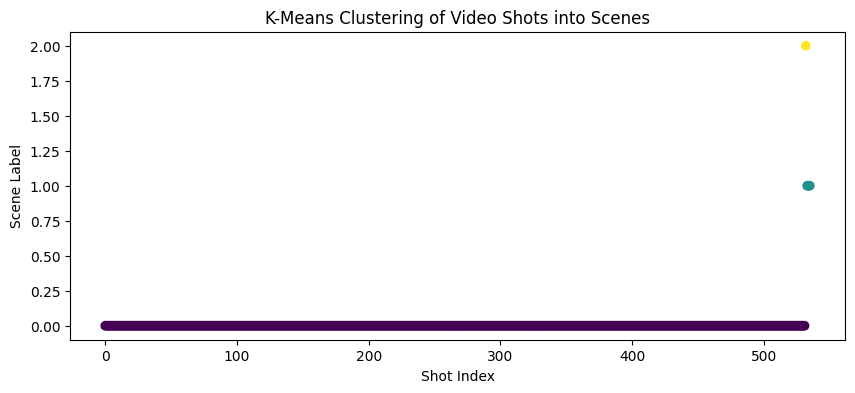

Scene distribution:
Scene 0: 532 shots
Scene 1: 3 shots
Scene 2: 1 shots

Showing 5 frames from Scene 0 (total 532 shots):


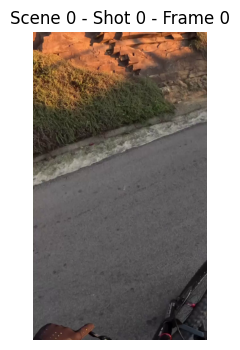

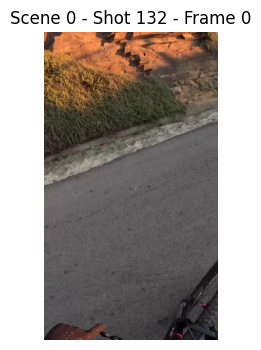

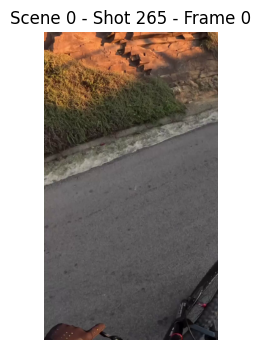

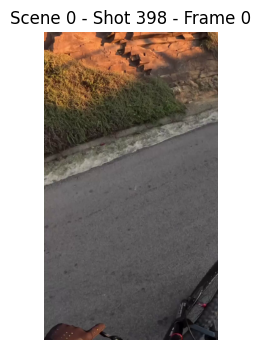

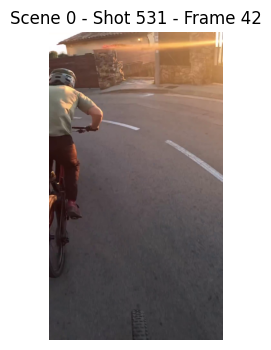


Showing 1 frames from Scene 1 (total 3 shots):


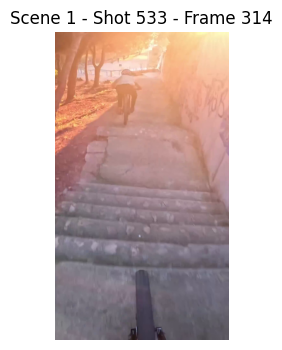


Showing 1 frames from Scene 2 (total 1 shots):


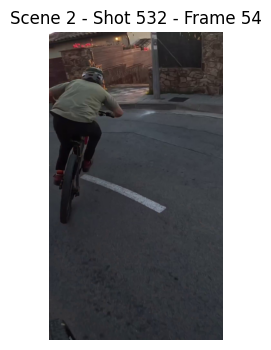

In [32]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def shot_features(video, cut_indices):
    cap = cv2.VideoCapture(video)
    if not cap.isOpened():
        print("Error: Can't open the video")
        return np.array([]), []
    
    feats = []
    start = 0
    
    flattened_cuts = []
    for item in cut_indices:
        if isinstance(item, (list, tuple, np.ndarray)):
            flattened_cuts.extend(item)
        else:
            flattened_cuts.append(item)
    
    cut_list = sorted([int(cut) for cut in flattened_cuts])
    cut_list.append(int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
    
    shot_starts = []
    
    for cut in cut_list:
        cap.set(cv2.CAP_PROP_POS_FRAMES, start)
        n = max(1, cut - start)
        sumc = np.zeros(3)
        
        for _ in range(n):
            ok, f = cap.read()
            if not ok:
                break
            hsv = cv2.cvtColor(f, cv2.COLOR_BGR2HSV)
            sumc += hsv.mean(axis=(0, 1))
        
        if n > 0:
            avg_hsv = sumc / n
            feats.append(avg_hsv)
            shot_starts.append(start) 
        
        start = cut
    
    cap.release()
    return np.array(feats), shot_starts

cuts = detect_cuts("/kaggle/input/videos3/147560-791705573.mp4", thresh=0.9)
feats, shot_starts = shot_features("/kaggle/input/videos3/147560-791705573.mp4", cuts)

if feats.size > 0:
    labels = KMeans(n_clusters=3, n_init=5, random_state=0).fit_predict(feats)
    
    # Plot the clustering results
    plt.figure(figsize=(10, 4))
    plt.scatter(range(len(labels)), labels, c=labels, cmap='viridis')
    plt.title("K-Means Clustering of Video Shots into Scenes")
    plt.xlabel("Shot Index")
    plt.ylabel("Scene Label")
    plt.show()
    
    # Group shots by scene labels
    scene_shots = {}
    for i, label in enumerate(labels):
        if label not in scene_shots:
            scene_shots[label] = []
        scene_shots[label].append((i, shot_starts[i]))
    
    # Display scene statistics
    unique_labels, counts = np.unique(labels, return_counts=True)
    print(f"Scene distribution:")
    for label, count in zip(unique_labels, counts):
        print(f"Scene {label}: {count} shots")
    
    # Open video for frame extraction
    cap = cv2.VideoCapture("/kaggle/input/videos3/147560-791705573.mp4")
    
    # Display frames from each scene
    frames_per_scene = [5, 1, 1]  # 5 from scene 0, 1 from scene 1, 1 from scene 2
    
    for scene_label in sorted(scene_shots.keys()):
        shots_in_scene = scene_shots[scene_label]
        frames_to_show = min(frames_per_scene[scene_label], len(shots_in_scene))
        
        print(f"\nShowing {frames_to_show} frames from Scene {scene_label} (total {len(shots_in_scene)} shots):")
        
        # Select evenly distributed shots from this scene
        if len(shots_in_scene) > 0:
            indices = np.linspace(0, len(shots_in_scene)-1, frames_to_show, dtype=int)
            selected_shots = [shots_in_scene[idx] for idx in indices]
            
            for shot_idx, frame_num in selected_shots:
                frame_num = int(frame_num)
                cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
                ret, frame = cap.read()
                
                if ret:
                    plt.figure(figsize=(6, 4))
                    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
                    plt.title(f"Scene {scene_label} - Shot {shot_idx} - Frame {frame_num}")
                    plt.axis("off")
                    plt.show()
                else:
                    print(f"Could not read frame {frame_num} for shot {shot_idx}")
    
    cap.release()
    
else:
    print("No features extracted. Please check the video and cut detection process.")

# Optical flow (Farneback)

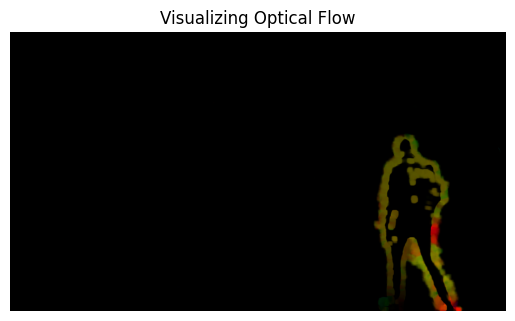

In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

cap = cv2.VideoCapture("/kaggle/input/videos1/282995_small.mp4")

if not cap.isOpened():
    print("Error: Can't open the video")
else:
    ok, prev = cap.read()
    if not ok:
        print("Error: Failed to read the first frame")
    else:
        prev_gray = cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY)

        flows = []
        max_frames = 100
        frame_count = 0

        while True:
            ok, frame = cap.read()
            if not ok or frame_count >= max_frames:
                break
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            flow = cv2.calcOpticalFlowFarneback(prev_gray, gray,
                                                None, 0.5, 3, 15, 3, 5, 1.2, 0)
            flows.append(flow)
            prev_gray = gray
            frame_count += 1

        cap.release()

        if len(flows) > 0:
            flow = flows[0]
            magnitude, angle = cv2.cartToPolar(flow[..., 0], flow[..., 1])

            hsv = np.zeros((flow.shape[0], flow.shape[1], 3), dtype=np.float32)
            hsv[..., 0] = angle * 180 / np.pi / 2
            hsv[..., 1] = 255
            hsv[..., 2] = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)

            bgr = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

            plt.imshow(bgr)
            plt.title("Visualizing Optical Flow")
            plt.axis('off')
            plt.show()

# Video augmentation

In [38]:
import torch, random, torchvision.transforms as T
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt

class VideoAugment:
    def __init__(self, size=224):
        self.spatial = T.Compose([
            T.Resize((size, size)),
            T.RandomHorizontalFlip(p=0.5),
            T.ColorJitter(0.2, 0.2, 0.2, 0.1)
        ])
    def __call__(self, clip):
        print(f"Applying spatial transformations to {len(clip)} frames.")
        return [self.spatial(img) for img in clip]

def temporal_reverse(clip):
    print(f"Reversing the temporal order of {len(clip)} frames.")
    return list(reversed(clip))

def temporal_subsample(clip, stride=2):
    print(f"Subsampling the clip with a stride of {stride}.")
    return clip[::stride]

cap = cv2.VideoCapture("/kaggle/input/videos1/282995_small.mp4")
if not cap.isOpened():
    print("Error: Cant open the video")
else:
    frames = []
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(Image.fromarray(frame))
    cap.release()

    print(f"Extracted {len(frames)} frames from the video.")
    
    video_augment = VideoAugment(size=224)
    
    augmented_frames = video_augment(frames)
    print(f"Applied augmentations, resulting in {len(augmented_frames)} frames.")

    reversed_frames = temporal_reverse(augmented_frames)
    print(f"Reversed the video, resulting in {len(reversed_frames)} frames.")

    subsampled_frames = temporal_subsample(reversed_frames, stride=5)
    print(f"Subsampled the video, resulting in {len(subsampled_frames)} frames.")
    
    out_path = "/kaggle/working/augmented_video.mp4"
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    fps = 30  
    w, h = augmented_frames[0].size
    out = cv2.VideoWriter(out_path, fourcc, fps, (w, h))
    
    for frame in subsampled_frames:
        frame = np.array(frame)
        frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
        out.write(frame)

    out.release()
    print(f"Augmented video saved to {out_path}")

Extracted 423 frames from the video.
Applying spatial transformations to 423 frames.
Applied augmentations, resulting in 423 frames.
Reversing the temporal order of 423 frames.
Reversed the video, resulting in 423 frames.
Subsampling the clip with a stride of 5.
Subsampled the video, resulting in 85 frames.
Augmented video saved to /kaggle/working/augmented_video.mp4


# Feature extraction

# Frame-level embeddings with ResNet (2D)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 214MB/s]


Extracted 423 frames from the video.
Processing frame 1/423
Processing frame 2/423
Processing frame 3/423
Processing frame 4/423
Processing frame 5/423
Processing frame 6/423
Processing frame 7/423
Processing frame 8/423
Processing frame 9/423
Processing frame 10/423
Processing frame 11/423
Processing frame 12/423
Processing frame 13/423
Processing frame 14/423
Processing frame 15/423
Processing frame 16/423
Processing frame 17/423
Processing frame 18/423
Processing frame 19/423
Processing frame 20/423
Processing frame 21/423
Processing frame 22/423
Processing frame 23/423
Processing frame 24/423
Processing frame 25/423
Processing frame 26/423
Processing frame 27/423
Processing frame 28/423
Processing frame 29/423
Processing frame 30/423
Processing frame 31/423
Processing frame 32/423
Processing frame 33/423
Processing frame 34/423
Processing frame 35/423
Processing frame 36/423
Processing frame 37/423
Processing frame 38/423
Processing frame 39/423
Processing frame 40/423
Processing f

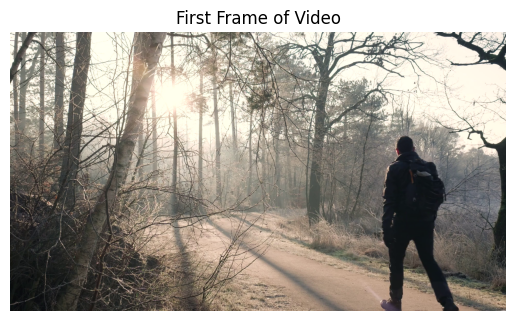

Embedding for the first frame: tensor([0.0312, 0.0731, 0.0930, 0.0000, 0.0014, 0.0022, 0.0027, 0.0031, 0.0089,
        0.0582])...


In [39]:
import torch
from torchvision import models, transforms
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt

resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2).eval()
pre = models.ResNet50_Weights.IMAGENET1K_V2.transforms()

@torch.no_grad()
def frame_embed(pil_img: Image.Image):
    x = pre(pil_img).unsqueeze(0)  
    feats = resnet.forward_features(x) if hasattr(resnet, "forward_features") else resnet.avgpool(resnet.layer4(resnet.layer3(resnet.layer2(resnet.layer1(resnet.relu(resnet.bn1(resnet.conv1(x))))))))
    if hasattr(resnet, "avgpool"):  
        feats = resnet.avgpool(resnet.layer4(resnet.layer3(resnet.layer2(resnet.layer1(resnet.relu(resnet.bn1(resnet.conv1(x))))))))
    vec = torch.flatten(feats, 1)   
    return vec.squeeze(0)

cap = cv2.VideoCapture("/kaggle/input/videos1/282995_small.mp4")
if not cap.isOpened():
    print("Error: Cant open the video")
else:
    frames = []
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        pil_frame = Image.fromarray(frame)
        frames.append(pil_frame)
    
    cap.release()

    print(f"Extracted {len(frames)} frames from the video.")
    
    video_embeddings = []
    for i, pil_frame in enumerate(frames):
        print(f"Processing frame {i+1}/{len(frames)}")
        embed = frame_embed(pil_frame)
        video_embeddings.append(embed)
    
    print(f"Extracted embeddings for {len(video_embeddings)} frames.")
    
    plt.imshow(np.array(frames[0]))
    plt.title("First Frame of Video")
    plt.axis('off')
    plt.show()
    
    print(f"Embedding for the first frame: {video_embeddings[0][:10]}...")